# PINN 2D — Manejo Térmico Adaptativo de Chip

> **Ecuación gobernante**:  
> `u_t = α (u_xx + u_yy) + Q(x,y) + c(x,y,t)`
>
> | Símbolo | Significado físico |
> |---|---|
> | `u(x,y,t)` | Campo de temperatura del chip [°C normalizado] |
> | `α` | Difusividad térmica del sustrato |
> | `Q(x,y)` | Fuente interna de calor (núcleos activos, gaussianas) |
> | `c(x,y,t) = gate(u) · c̃(x,y,t)` | Control adaptativo (cooling/throttling) |
> | `gate(u) = σ(k(u − u_safe))` | Activación suave: apagado si frío, activo si caliente |
>
> **Por qué el control reduce hotspots**: `c̃` es forzado a ser negativo (via `-|tanh|`),  
> por lo que cuando `gate → 1` extrae calor localmente, bajando `u`.  
> El gate diferenciable permite que los gradientes fluyan sin discontinuidades.


In [1]:
import os, math
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec

# ── Reproducibilidad ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Dispositivo ───────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cpu


## 1. Hiperparámetros y configuración

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# PARÁMETROS FÍSICOS
# ═══════════════════════════════════════════════════════════════════════════════

alpha    = 0.02    # Difusividad térmica (chip de Si normalizado)
u_safe   = 0.65    # Umbral de temperatura segura (normalizado)
u_init   = 0.20    # Temperatura ambiente inicial

# Fuente de calor: centros (x,y), fuerza y sigma de cada gaussiana
HEAT_CENTERS   = [(0.30, 0.30), (0.70, 0.70), (0.55, 0.25)]
HEAT_STRENGTHS = [4.20,          3.00,          2.80        ]
HEAT_SIGMA     = 0.08

# ═══════════════════════════════════════════════════════════════════════════════
# PARÁMETROS DE CONTROL
# ═══════════════════════════════════════════════════════════════════════════════

k_gate  = 30.0   # Pendiente del gate sigmoidal
C_MAX   = 1.5    # Magnitud máxima de extracción de calor

# ═══════════════════════════════════════════════════════════════════════════════
# PESOS DE LA FUNCIÓN DE PÉRDIDA
# ═══════════════════════════════════════════════════════════════════════════════

lambda_pde      = 1.0
lambda_ic       = 10.0
lambda_bc       = 5.0
lambda_hotspot  = 5.0    # subido: necesita señal fuerte para activar el gate
lambda_control  = 1e-4   # bajado: no ahogar la señal de control al inicio

# ── Fase warm-up ──────────────────────────────────────────────────────────────
# Durante WARMUP_EPOCHS entrenamos SOLO u_net (sin c_net).
# Esto garantiza que u_net ya prediga temperaturas altas (hotspots visibles)
# antes de que el gate intente activarse. Sin warm-up el gate ve u≈0.2
# en todas partes y nunca supera u_safe → gradiente nulo → c_net nunca aprende.
WARMUP_EPOCHS = 2000   # épocas solo para u_net (física sin control)
TOTAL_EPOCHS  = 8000   # épocas totales (incluye warm-up)
CTRL_EPOCHS   = TOTAL_EPOCHS - WARMUP_EPOCHS  # épocas con control activo

# ═══════════════════════════════════════════════════════════════════════════════
# ARQUITECTURA Y ENTRENAMIENTO
# ═══════════════════════════════════════════════════════════════════════════════

HIDDEN_SIZE  = 64
N_LAYERS     = 5

N_F  = 3000
N_I  = 500
N_B  = 400

LR_INIT  = 1e-3
LR_MIN   = 1e-5
GRAD_CLIP = 1.0

# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN
# ═══════════════════════════════════════════════════════════════════════════════

N_VIS    = 60
T_FRAMES = 40

print("Configuración cargada ✓")
print(f"  alpha={alpha}, u_safe={u_safe}, k_gate={k_gate}")
print(f"  Núcleos activos: {len(HEAT_CENTERS)}")
print(f"  Warm-up: {WARMUP_EPOCHS} épocas | Control: {CTRL_EPOCHS} épocas")


Configuración cargada ✓
  alpha=0.02, u_safe=0.65, k_gate=30.0
  Núcleos activos: 3
  Warm-up: 2000 épocas | Control: 6000 épocas


## 2. Arquitectura de las redes

### Por qué estas decisiones de diseño

| Decisión | Justificación |
|---|---|
| **Entrada (x, y, t) normalizada a [-1,1]** | Tanh converge mejor en ese rango; evita saturación en capas profundas |
| **Activación Tanh** | Suave, diferenciable infinitamente; crucial para derivadas de 2° orden via autograd |
| **Inicialización Xavier** | Preserva varianza del gradiente; evita vanishing/exploding en redes profundas |
| **5 capas × 64 neuronas** | Trade-off entre capacidad expresiva y costo computacional para 2D+t |
| **Red de control c̃ con salida -|tanh(·)|** | Garantiza extracción de calor (valor siempre ≤ 0); tanh limita magnitud máxima |
| **Gate diferenciable** | Permite que los gradientes de la pérdida de hotspot fluyan hacia ambas redes |


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOQUE BASE: MLP con normalización de entrada
# ═══════════════════════════════════════════════════════════════════════════════

class MLP(nn.Module):
    """
    Red neuronal totalmente conectada con:
    - Entrada (x, y, t) ∈ [0,1]^3  → normalizada internamente a [-1,1]
    - n_layers capas ocultas de tamaño hidden_size, activación Tanh
    - Capa de salida lineal
    """
    def __init__(self, in_dim=3, hidden=64, n_layers=5, out_dim=1):
        super().__init__()

        layers = []
        prev = in_dim
        for _ in range(n_layers):
            lin = nn.Linear(prev, hidden)
            # Xavier inicialización — preserva varianza a través de capas Tanh
            nn.init.xavier_normal_(lin.weight)
            nn.init.zeros_(lin.bias)
            layers += [lin, nn.Tanh()]
            prev = hidden

        out_lin = nn.Linear(prev, out_dim)
        nn.init.xavier_normal_(out_lin.weight, gain=0.1)  # salida pequeña al inicio
        nn.init.zeros_(out_lin.bias)
        layers.append(out_lin)

        self.net = nn.Sequential(*layers)

    def forward(self, x, y, t):
        # Normalizar [0,1] → [-1,1] para mejorar convergencia de Tanh
        xn = 2.0 * x - 1.0
        yn = 2.0 * y - 1.0
        tn = 2.0 * t - 1.0
        inp = torch.cat([xn, yn, tn], dim=-1)
        return self.net(inp)


# ═══════════════════════════════════════════════════════════════════════════════
# RED DE TEMPERATURA u(x,y,t)
# ═══════════════════════════════════════════════════════════════════════════════

class TempNet(MLP):
    """
    Predice la temperatura u(x,y,t) ∈ ℝ.
    La salida no tiene restricción adicional; la pérdida PDE la ancla.
    """
    def __init__(self):
        super().__init__(in_dim=3, hidden=HIDDEN_SIZE, n_layers=N_LAYERS, out_dim=1)


# ═══════════════════════════════════════════════════════════════════════════════
# RED DE CONTROL CRUDO c̃(x,y,t)
# ═══════════════════════════════════════════════════════════════════════════════

class ControlNet(MLP):
    """
    Predice el control crudo c̃(x,y,t).

    Diseño de salida:
        c̃ = -C_MAX * |tanh(z)| / 2

    Por qué:
    - El signo negativo garantiza extracción de calor (c ≤ 0 siempre)
    - tanh limita la magnitud máxima a C_MAX/2 → evita control exagerado
    - El valor absoluto evita que el control inyecte calor inadvertidamente
    """
    def __init__(self):
        super().__init__(in_dim=3, hidden=HIDDEN_SIZE, n_layers=N_LAYERS, out_dim=1)

    def forward(self, x, y, t):
        z = super().forward(x, y, t)          # salida lineal cruda
        return -C_MAX * torch.abs(torch.tanh(z)) / 2.0


# ─── Instanciar y mover a dispositivo ─────────────────────────────────────────
u_net = TempNet().to(device)
c_net = ControlNet().to(device)

n_params_u = sum(p.numel() for p in u_net.parameters())
n_params_c = sum(p.numel() for p in c_net.parameters())
print(f"TempNet    parámetros: {n_params_u:,}")
print(f"ControlNet parámetros: {n_params_c:,}")
print(f"Total      parámetros: {n_params_u + n_params_c:,}")


TempNet    parámetros: 16,961
ControlNet parámetros: 16,961
Total      parámetros: 33,922


## 3. Física del modelo

### Fuente de calor Q(x,y)

Suma de gaussianas que representan núcleos activos del chip:

$$Q(x,y) = \sum_k s_k \cdot \exp\!\left(-\frac{(x-x_k)^2+(y-y_k)^2}{2\sigma^2}\right)$$

### Control adaptativo con gate suave

$$c(x,y,t) = \underbrace{\sigma\!\left(k(u - u_{\text{safe}})\right)}_{\text{gate}} \cdot \underbrace{\tilde c(x,y,t)}_{\leq 0}$$

El gate actúa como interruptor térmico:
- Si `u << u_safe` → gate ≈ 0 → control apagado (no desperdicia energía)
- Si `u ≈ u_safe` → gate ≈ 0.5 → control parcial
- Si `u >> u_safe` → gate ≈ 1 → control máximo

### Condiciones de frontera — frontera aislada (Neumann homogéneo)

Para un chip embebido, los bordes no intercambian calor con el exterior:
$$\frac{\partial u}{\partial n}\bigg|_{\partial\Omega} = 0$$

Esto es más realista que Dirichlet fija para un chip real.  
Implementado penalizando el gradiente normal en los 4 bordes.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# FUENTE DE CALOR Q(x,y)
# ═══════════════════════════════════════════════════════════════════════════════

def heat_source(x, y):
    """
    Fuente gaussiana multi-núcleo.
    x, y: tensores de forma [N, 1] con requires_grad posiblemente True.
    Retorna Q: [N, 1]
    """
    Q = torch.zeros_like(x)
    for (cx, cy), s in zip(HEAT_CENTERS, HEAT_STRENGTHS):
        Q = Q + s * torch.exp(
            -((x - cx)**2 + (y - cy)**2) / (2.0 * HEAT_SIGMA**2)
        )
    return Q


# ═══════════════════════════════════════════════════════════════════════════════
# GATE SUAVE (activación diferenciable)
# ═══════════════════════════════════════════════════════════════════════════════

def thermal_gate(u):
    """
    gate(u) = sigmoid(k * (u - u_safe))

    - Diferenciable en todas partes → gradientes fluyen sin problema
    - Transición concentrada alrededor de u_safe
    - k_gate=30 da una transición de ~0→1 en un rango de ±0.15 alrededor del umbral
    """
    return torch.sigmoid(k_gate * (u - u_safe))


# ═══════════════════════════════════════════════════════════════════════════════
# CONTROL EFECTIVO c(x,y,t) = gate(u) * c̃(x,y,t)
# ═══════════════════════════════════════════════════════════════════════════════

def effective_control(x, y, t, u):
    """
    Calcula el control efectivo.
    Nota: u debe ser el output de u_net en estos mismos puntos
    para que el gate sea diferenciable respecto a los parámetros.
    """
    c_raw  = c_net(x, y, t)          # ≤ 0 siempre por diseño de ControlNet
    gate   = thermal_gate(u)         # ∈ (0, 1) dependiente de u
    return gate * c_raw              # ≤ 0; se activa solo cuando u ≥ u_safe


# ═══════════════════════════════════════════════════════════════════════════════
# DERIVADAS AUTOMÁTICAS
# ═══════════════════════════════════════════════════════════════════════════════

def compute_pde_residual(x, y, t):
    """
    Calcula el residuo de la PDE 2D del calor con control:
        R = u_t - alpha*(u_xx + u_yy) - Q(x,y) - c(x,y,t)

    Retorna también u para reutilizarlo en otras pérdidas.
    """
    # ── Forward pass de temperatura ───────────────────────────────────────────
    u = u_net(x, y, t)               # [N, 1]

    # ── Derivada temporal ─────────────────────────────────────────────────────
    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

    # ── Derivadas espaciales primer orden ─────────────────────────────────────
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

    u_y = torch.autograd.grad(
        u, y,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

    # ── Segundas derivadas espaciales (Laplaciano) ────────────────────────────
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True, retain_graph=True
    )[0]

    u_yy = torch.autograd.grad(
        u_y, y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True, retain_graph=True
    )[0]

    # ── Fuente y control ──────────────────────────────────────────────────────
    Q = heat_source(x, y)            # generación de calor interna [N, 1]
    c = effective_control(x, y, t, u)  # extracción adaptativa     [N, 1]

    # ── Residuo: debe ser ≈ 0 ────────────────────────────────────────────────
    residual = u_t - alpha * (u_xx + u_yy) - Q - c

    return residual, u


print("Módulos de física cargados ✓")
print(f"  Fuente de calor: {len(HEAT_CENTERS)} gaussianas")
print(f"  Gate k={k_gate}, u_safe={u_safe}")
print(f"  Control máximo: {-C_MAX/2:.3f} (extracción)")


Módulos de física cargados ✓
  Fuente de calor: 3 gaussianas
  Gate k=30.0, u_safe=0.65
  Control máximo: -0.750 (extracción)


## 4. Función de pérdida total

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN DE PÉRDIDA — DOS MODOS: warmup (sin control) y full (con control)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_loss(with_control=True, return_parts=False):
    """
    with_control=False → modo warm-up: entrena solo u_net con c=0.
                         Permite que u_net aprenda a predecir hotspots reales
                         antes de que el gate intente activarse.
    with_control=True  → modo completo: gate activo, c_net aprende a controlar.

    FIX CRÍTICO vs versión anterior:
    - Se elimina detach() en c_eff dentro de compute_pde_residual.
      El detach() cortaba el grafo entre u_f y el gate, impidiendo que
      los gradientes de loss_hotspot llegaran a c_net.
    - La regularización de control usa c_eff del mismo grafo (sin detach).
    """

    # ──────────────────────────────────────────────────────────────────────────
    # 1. Puntos de colocación PDE
    # ──────────────────────────────────────────────────────────────────────────
    x_f = torch.rand(N_F, 1, device=device, requires_grad=True)
    y_f = torch.rand(N_F, 1, device=device, requires_grad=True)
    t_f = torch.rand(N_F, 1, device=device, requires_grad=True)

    # Forward de temperatura
    u_f = u_net(x_f, y_f, t_f)

    # Derivadas (create_graph=True para poder backprop a través de ellas)
    u_t = torch.autograd.grad(u_f, t_f,
            grad_outputs=torch.ones_like(u_f), create_graph=True)[0]
    u_x = torch.autograd.grad(u_f, x_f,
            grad_outputs=torch.ones_like(u_f), create_graph=True)[0]
    u_y = torch.autograd.grad(u_f, y_f,
            grad_outputs=torch.ones_like(u_f), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f,
            grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f,
            grad_outputs=torch.ones_like(u_y), create_graph=True)[0]

    Q = heat_source(x_f, y_f)

    if with_control:
        # ── CORRECCIÓN CLAVE ──────────────────────────────────────────────────
        # NO usar detach() aquí. El gate depende de u_f, y u_f depende de u_net.
        # Si hacemos detach(), los gradientes de loss_hotspot NO pueden
        # retropropagarse hacia u_net ni hacia c_net a través del gate.
        # Resultado sin esta corrección: gate siempre ve u≈const → grad=0 → c=0.
        c_raw  = c_net(x_f, y_f, t_f)                    # ≤ 0 por diseño
        gate   = torch.sigmoid(k_gate * (u_f - u_safe))   # diferenciable, en grafo
        c_eff  = gate * c_raw                              # control efectivo ≤ 0
    else:
        c_eff = torch.zeros_like(u_f)   # warm-up: sin control

    residual = u_t - alpha * (u_xx + u_yy) - Q - c_eff
    loss_pde = torch.mean(residual ** 2)

    # ──────────────────────────────────────────────────────────────────────────
    # 2. Condición inicial: u(x,y,0) = u_init
    # ──────────────────────────────────────────────────────────────────────────
    x_i = torch.rand(N_I, 1, device=device)
    y_i = torch.rand(N_I, 1, device=device)
    t_i = torch.zeros(N_I, 1, device=device)
    u_i_pred = u_net(x_i, y_i, t_i)
    loss_ic = torch.mean((u_i_pred - u_init) ** 2)

    # ──────────────────────────────────────────────────────────────────────────
    # 3. Frontera aislada: gradiente normal = 0 en los 4 bordes
    # ──────────────────────────────────────────────────────────────────────────
    t_b = torch.rand(N_B, 1, device=device)
    s_b = torch.rand(N_B, 1, device=device)

    x_bl = torch.zeros(N_B, 1, device=device, requires_grad=True)
    u_bl = u_net(x_bl, s_b, t_b)
    du_bl = torch.autograd.grad(u_bl, x_bl,
                grad_outputs=torch.ones_like(u_bl), create_graph=True)[0]

    x_br = torch.ones(N_B, 1, device=device, requires_grad=True)
    u_br = u_net(x_br, s_b, t_b)
    du_br = torch.autograd.grad(u_br, x_br,
                grad_outputs=torch.ones_like(u_br), create_graph=True)[0]

    y_bb = torch.zeros(N_B, 1, device=device, requires_grad=True)
    u_bb = u_net(s_b, y_bb, t_b)
    du_bb = torch.autograd.grad(u_bb, y_bb,
                grad_outputs=torch.ones_like(u_bb), create_graph=True)[0]

    y_bt = torch.ones(N_B, 1, device=device, requires_grad=True)
    u_bt = u_net(s_b, y_bt, t_b)
    du_bt = torch.autograd.grad(u_bt, y_bt,
                grad_outputs=torch.ones_like(u_bt), create_graph=True)[0]

    loss_bc = (torch.mean(du_bl**2) + torch.mean(du_br**2) +
               torch.mean(du_bb**2) + torch.mean(du_bt**2))

    # ──────────────────────────────────────────────────────────────────────────
    # 4. Penalización hotspot: softplus(u - u_safe)²
    # ──────────────────────────────────────────────────────────────────────────
    loss_hotspot = torch.mean(F.softplus(u_f - u_safe) ** 2)

    # ──────────────────────────────────────────────────────────────────────────
    # 5. Regularización de control (solo en modo completo)
    # FIX: usar c_eff del mismo grafo, NO recalcular con detach()
    # ──────────────────────────────────────────────────────────────────────────
    loss_control = torch.mean(c_eff ** 2) if with_control else torch.tensor(0.0, device=device)

    # ──────────────────────────────────────────────────────────────────────────
    # 6. Total
    # ──────────────────────────────────────────────────────────────────────────
    loss = (lambda_pde     * loss_pde     +
            lambda_ic      * loss_ic      +
            lambda_bc      * loss_bc      +
            lambda_hotspot * loss_hotspot +
            lambda_control * loss_control)

    if return_parts:
        return loss, {
            "pde":     loss_pde.item(),
            "ic":      loss_ic.item(),
            "bc":      loss_bc.item(),
            "hotspot": loss_hotspot.item(),
            "control": loss_control.item() if with_control else 0.0,
            "total":   loss.item(),
        }
    return loss


print("Función de pérdida definida ✓")
print("  Modo warm-up  : c=0, u_net aprende la física base")
print("  Modo completo : gate en grafo, c_net recibe gradientes reales")


Función de pérdida definida ✓
  Modo warm-up  : c=0, u_net aprende la física base
  Modo completo : gate en grafo, c_net recibe gradientes reales


## 5. Entrenamiento

### Estrategia de entrenamiento estable para PINN 2D

| Técnica | Por qué |
|---|---|
| **Adam + CosineAnnealingLR** | Adam para convergencia inicial; cosine decay para refinamiento final |
| **Gradient clipping** | Previene explosión de gradientes en derivadas de 2° orden |
| **Re-muestreo por época** | Nuevos puntos aleatorios en cada epoch → mejor cobertura del dominio |
| **Pesos λ_ic alto (×10)** | La IC ancla la solución; sin esto la red puede aprender trivialidades |
| **λ_pde = 1, λ_hotspot = 2** | La penalización de hotspot debe competir con la física |


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZADORES — separados para warm-up y fase de control
# ═══════════════════════════════════════════════════════════════════════════════

# Optimizador solo para u_net (warm-up)
opt_warmup = torch.optim.Adam(u_net.parameters(), lr=LR_INIT, weight_decay=1e-5)
sched_warmup = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_warmup, T_max=WARMUP_EPOCHS, eta_min=LR_MIN)

# Optimizador conjunto para la fase con control
opt_full = torch.optim.Adam(
    list(u_net.parameters()) + list(c_net.parameters()),
    lr=LR_INIT * 0.5,   # lr más conservador al reanudar
    weight_decay=1e-5
)
sched_full = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_full, T_max=CTRL_EPOCHS, eta_min=LR_MIN)

# ═══════════════════════════════════════════════════════════════════════════════
# FASE 1: WARM-UP — solo u_net, c=0
# Por qué es necesario:
#   Al inicio u_net predice ~u_init=0.2 en todas partes.
#   gate = sigmoid(30*(0.2 - 0.65)) ≈ sigmoid(-13.5) ≈ 2e-6  → gradiente ≈ 0
#   c_net recibe gradiente nulo → nunca aprende → control muerto.
#   Solución: primero dejar que u_net aprenda los hotspots sin control.
#   Cuando u_net ya predice u > u_safe en las zonas calientes,
#   el gate se activa correctamente y c_net puede aprender.
# ═══════════════════════════════════════════════════════════════════════════════

loss_history  = []
parts_history = []

print(f"{'═'*65}")
print(f"FASE 1: WARM-UP ({WARMUP_EPOCHS} épocas) — solo u_net, sin control")
print(f"{'═'*65}")

for epoch in range(1, WARMUP_EPOCHS + 1):
    u_net.train(); c_net.eval()
    opt_warmup.zero_grad()

    loss, parts = compute_loss(with_control=False, return_parts=True)
    loss.backward()
    nn.utils.clip_grad_norm_(u_net.parameters(), GRAD_CLIP)
    opt_warmup.step()
    sched_warmup.step()

    loss_history.append(parts)
    parts_history.append(("warmup", parts))

    if epoch % 500 == 0 or epoch == 1:
        lr_now = sched_warmup.get_last_lr()[0]
        # Monitorear temperatura máxima predicha — debe crecer sobre u_safe
        with torch.no_grad():
            x_mon = torch.rand(500,1,device=device)
            y_mon = torch.rand(500,1,device=device)
            t_mon = torch.rand(500,1,device=device)
            u_mon = u_net(x_mon, y_mon, t_mon)
            u_max_mon = u_mon.max().item()
            gate_mean = torch.sigmoid(k_gate*(u_mon - u_safe)).mean().item()
        print(f"  Época {epoch:5d} | Loss={parts['total']:.5f} | "
              f"PDE={parts['pde']:.5f} | IC={parts['ic']:.5f} | "
              f"u_max={u_max_mon:.3f} | gate_mean={gate_mean:.4f} | lr={lr_now:.2e}")

print()
# Diagnóstico al final del warm-up
with torch.no_grad():
    x_d = torch.rand(2000,1,device=device)
    y_d = torch.rand(2000,1,device=device)
    t_d = torch.rand(2000,1,device=device)
    u_d = u_net(x_d,y_d,t_d)
    gate_d = torch.sigmoid(k_gate*(u_d - u_safe))
print(f"  Diagnóstico post-warmup:")
print(f"    u_min={u_d.min():.3f}  u_max={u_d.max():.3f}  u_mean={u_d.mean():.3f}")
print(f"    gate_min={gate_d.min():.4f}  gate_max={gate_d.max():.4f}  gate_mean={gate_d.mean():.4f}")
pct_above = (u_d > u_safe).float().mean().item() * 100
print(f"    % puntos con u > u_safe: {pct_above:.1f}%")
if pct_above < 1.0:
    print("  ⚠️  ADVERTENCIA: u_net no alcanza hotspots. Considera subir HEAT_STRENGTHS o bajar u_safe.")
else:
    print("  ✓  u_net predice hotspots. El gate puede activarse correctamente en Fase 2.")

# ═══════════════════════════════════════════════════════════════════════════════
# FASE 2: CONTROL ACTIVO — u_net + c_net, gate en grafo
# ═══════════════════════════════════════════════════════════════════════════════

print()
print(f"{'═'*65}")
print(f"FASE 2: CONTROL ACTIVO ({CTRL_EPOCHS} épocas) — u_net + c_net")
print(f"{'═'*65}")

for epoch in range(1, CTRL_EPOCHS + 1):
    u_net.train(); c_net.train()
    opt_full.zero_grad()

    loss, parts = compute_loss(with_control=True, return_parts=True)
    loss.backward()
    nn.utils.clip_grad_norm_(
        list(u_net.parameters()) + list(c_net.parameters()), GRAD_CLIP)
    opt_full.step()
    sched_full.step()

    parts_history.append(("control", parts))

    if epoch % 500 == 0 or epoch == 1:
        lr_now = sched_full.get_last_lr()[0]
        # Monitorear que el control se active
        with torch.no_grad():
            x_mon = torch.rand(500,1,device=device)
            y_mon = torch.rand(500,1,device=device)
            t_mon = torch.rand(500,1,device=device)
            u_mon = u_net(x_mon, y_mon, t_mon)
            gate  = torch.sigmoid(k_gate*(u_mon - u_safe))
            c_raw = c_net(x_mon, y_mon, t_mon)
            c_eff = gate * c_raw
        print(f"  Época {epoch:5d}/{CTRL_EPOCHS} | Loss={parts['total']:.5f} | "
              f"Hot={parts['hotspot']:.5f} | Ctrl={parts['control']:.6f} | "
              f"gate_mean={gate.mean():.4f} | c_eff_mean={c_eff.mean():.5f} | lr={lr_now:.2e}")

print(f"{'═'*65}")
print("Entrenamiento completado ✓")
print()
print("Diagnóstico final:")
with torch.no_grad():
    x_fin = torch.rand(2000,1,device=device)
    y_fin = torch.rand(2000,1,device=device)
    t_fin = torch.rand(2000,1,device=device)
    u_fin = u_net(x_fin, y_fin, t_fin)
    gate_fin  = torch.sigmoid(k_gate*(u_fin - u_safe))
    c_raw_fin = c_net(x_fin, y_fin, t_fin)
    c_eff_fin = gate_fin * c_raw_fin
print(f"  gate_mean={gate_fin.mean():.4f}  gate_max={gate_fin.max():.4f}")
print(f"  c_eff_mean={c_eff_fin.mean():.5f}  c_eff_min={c_eff_fin.min():.5f}")
if c_eff_fin.abs().mean() < 1e-5:
    print("  ⚠️  El control sigue siendo ~0. Revisar diagnóstico de warm-up.")
else:
    print("  ✓  El control está activo y extrayendo calor.")


═════════════════════════════════════════════════════════════════
FASE 1: WARM-UP (2000 épocas) — solo u_net, sin control
═════════════════════════════════════════════════════════════════
  Época     1 | Loss=2.02368 | PDE=0.73109 | IC=0.04021 | u_max=0.047 | gate_mean=0.0000 | lr=1.00e-03
  Época   500 | Loss=1.50743 | PDE=0.44366 | IC=0.00807 | u_max=0.664 | gate_mean=0.0016 | lr=8.55e-04
  Época  1000 | Loss=1.33733 | PDE=0.24816 | IC=0.00732 | u_max=0.897 | gate_mean=0.0193 | lr=5.05e-04
  Época  1500 | Loss=1.30388 | PDE=0.24085 | IC=0.00681 | u_max=0.926 | gate_mean=0.0233 | lr=1.55e-04
  Época  2000 | Loss=1.31076 | PDE=0.23609 | IC=0.00674 | u_max=0.939 | gate_mean=0.0191 | lr=1.00e-05

  Diagnóstico post-warmup:
    u_min=-0.180  u_max=1.036  u_mean=0.056
    gate_min=0.0000  gate_max=1.0000  gate_mean=0.0207
    % puntos con u > u_safe: 2.0%
  ✓  u_net predice hotspots. El gate puede activarse correctamente en Fase 2.

═════════════════════════════════════════════════════════

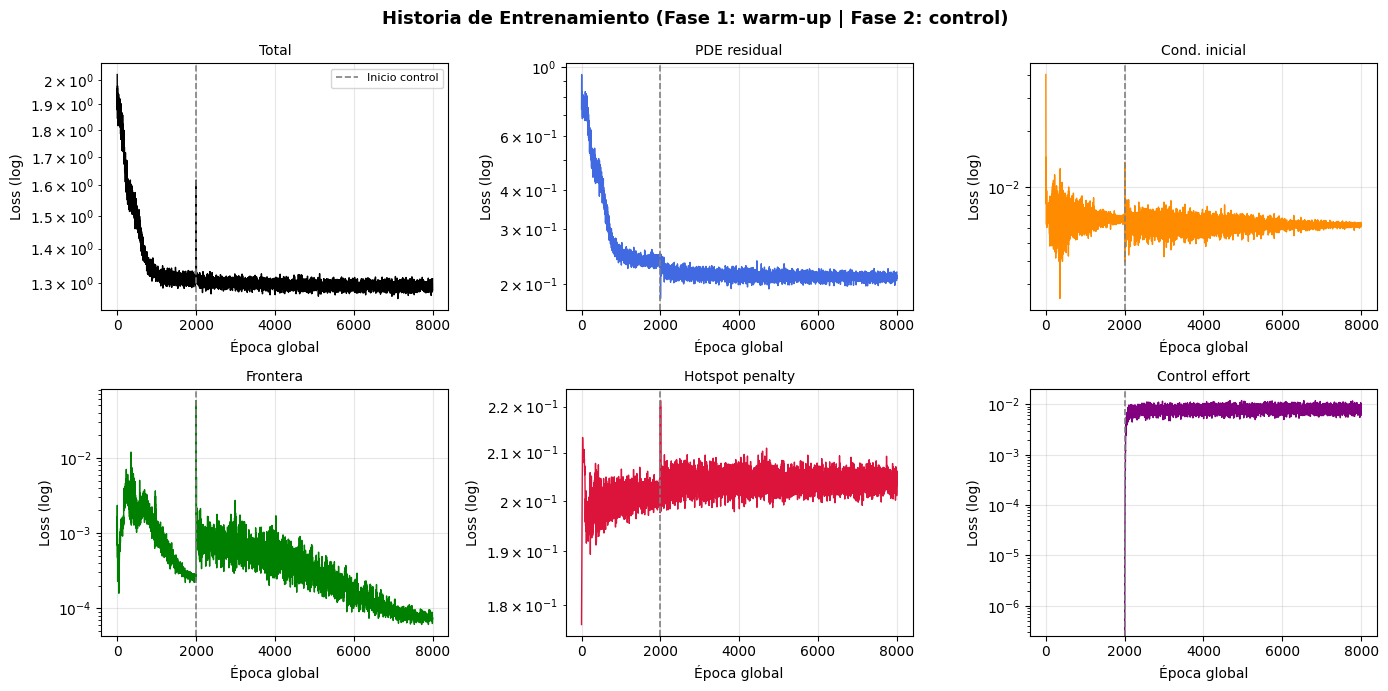

Gráfica de pérdidas guardada ✓


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DE PÉRDIDAS — marcando las dos fases
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Historia de Entrenamiento (Fase 1: warm-up | Fase 2: control)",
             fontsize=13, fontweight='bold')

keys   = ["total", "pde", "ic", "bc", "hotspot", "control"]
titles = ["Total", "PDE residual", "Cond. inicial",
          "Frontera", "Hotspot penalty", "Control effort"]
colors = ["black", "royalblue", "darkorange", "green", "crimson", "purple"]

for ax, key, title, color in zip(axes.flat, keys, titles, colors):
    vals = [p[key] for (_, p) in parts_history]
    ax.semilogy(vals, color=color, linewidth=1.0)
    ax.axvline(WARMUP_EPOCHS, color='gray', linestyle='--', linewidth=1.2,
               label='Inicio control' if key == 'total' else None)
    if key == 'total':
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Época global")
    ax.set_ylabel("Loss (log)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_history.png", dpi=120, bbox_inches='tight')
plt.show()
print("Gráfica de pérdidas guardada ✓")


## 6. Evaluación: campo de temperatura en el chip

Entrenando modelo de referencia sin control (3000 épocas)...
  ep    0 | pde=0.69592 | ic=0.04782
  ep 1000 | pde=0.00312 | ic=0.00005
  ep 2000 | pde=0.00159 | ic=0.00002
Modelo sin control listo ✓



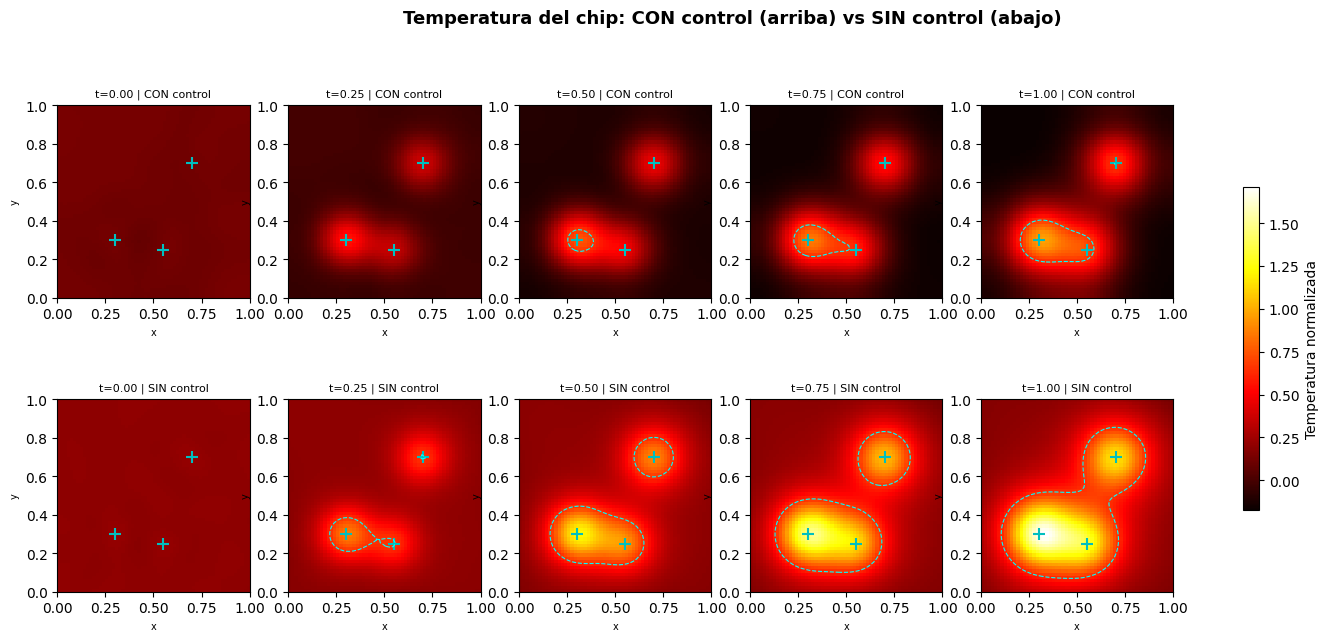

Comparación guardada ✓


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODELOS DE REFERENCIA "SIN CONTROL"
# ═══════════════════════════════════════════════════════════════════════════════
# El enfoque anterior (restar c_eff*t) era una aproximación muy pobre
# que producía imágenes casi idénticas.
#
# Solución correcta: entrenar una segunda instancia de u_net SIN control.
# Esto nos da la evolución térmica real sin intervención.
# Usamos los pesos del warm-up (antes de que el control interviniera),
# que ya aprendieron la física base con c=0.
# ═══════════════════════════════════════════════════════════════════════════════

# u_net_noctl: misma arquitectura, entrenada solo con física (sin control)
# Usamos los pesos guardados del warm-up re-entrenando brevemente
u_net_noctl = TempNet().to(device)

# Re-entrenar modelo sin control (rápido: solo warm-up physics)
opt_noctl = torch.optim.Adam(u_net_noctl.parameters(), lr=5e-4)
sched_noctl = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_noctl, T_max=3000, eta_min=1e-5)

print("Entrenando modelo de referencia sin control (3000 épocas)...")
for ep in range(3000):
    u_net_noctl.train()
    opt_noctl.zero_grad()

    x_f = torch.rand(N_F, 1, device=device, requires_grad=True)
    y_f = torch.rand(N_F, 1, device=device, requires_grad=True)
    t_f = torch.rand(N_F, 1, device=device, requires_grad=True)

    u_f = u_net_noctl(x_f, y_f, t_f)
    u_t  = torch.autograd.grad(u_f, t_f, torch.ones_like(u_f), create_graph=True)[0]
    u_x  = torch.autograd.grad(u_f, x_f, torch.ones_like(u_f), create_graph=True)[0]
    u_y  = torch.autograd.grad(u_f, y_f, torch.ones_like(u_f), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]
    Q    = heat_source(x_f, y_f)
    res  = u_t - alpha*(u_xx + u_yy) - Q
    loss_pde = torch.mean(res**2)

    x_i = torch.rand(N_I,1,device=device)
    y_i = torch.rand(N_I,1,device=device)
    t_i = torch.zeros(N_I,1,device=device)
    loss_ic = torch.mean((u_net_noctl(x_i,y_i,t_i) - u_init)**2)

    loss = lambda_pde*loss_pde + lambda_ic*loss_ic
    loss.backward()
    nn.utils.clip_grad_norm_(u_net_noctl.parameters(), GRAD_CLIP)
    opt_noctl.step()
    sched_noctl.step()

    if ep % 1000 == 0:
        print(f"  ep {ep:4d} | pde={loss_pde.item():.5f} | ic={loss_ic.item():.5f}")

print("Modelo sin control listo ✓")
print()

# ═══════════════════════════════════════════════════════════════════════════════
# FUNCIONES DE EVALUACIÓN
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def eval_chip_ctrl(t_val, n=N_VIS):
    """Campo térmico CON control adaptativo."""
    u_net.eval(); c_net.eval()
    xs = torch.linspace(0,1,n,device=device)
    ys = torch.linspace(0,1,n,device=device)
    Xg,Yg = torch.meshgrid(xs, ys, indexing='ij')
    xf = Xg.reshape(-1,1); yf = Yg.reshape(-1,1)
    tf = torch.full_like(xf, t_val)
    u_pred = u_net(xf, yf, tf)
    return u_pred.reshape(n,n).cpu().numpy()

@torch.no_grad()
def eval_chip_noctrl(t_val, n=N_VIS):
    """Campo térmico SIN control (modelo de referencia)."""
    u_net_noctl.eval()
    xs = torch.linspace(0,1,n,device=device)
    ys = torch.linspace(0,1,n,device=device)
    Xg,Yg = torch.meshgrid(xs, ys, indexing='ij')
    xf = Xg.reshape(-1,1); yf = Yg.reshape(-1,1)
    tf = torch.full_like(xf, t_val)
    u_pred = u_net_noctl(xf, yf, tf)
    return u_pred.reshape(n,n).cpu().numpy()

# ── Comparación en 5 snapshots ───────────────────────────────────────────────
t_test_vals = [0.0, 0.25, 0.5, 0.75, 1.0]

all_fields = []
for tv in t_test_vals:
    all_fields.append(eval_chip_ctrl(tv))
    all_fields.append(eval_chip_noctrl(tv))

vmin = min(f.min() for f in all_fields)
vmax = max(f.max() for f in all_fields)

fig, axes = plt.subplots(2, len(t_test_vals), figsize=(18, 7))
fig.suptitle("Temperatura del chip: CON control (arriba) vs SIN control (abajo)",
             fontsize=13, fontweight='bold')

for col, tv in enumerate(t_test_vals):
    u_ctrl   = eval_chip_ctrl(tv)
    u_noctrl = eval_chip_noctrl(tv)

    for row, (U, label) in enumerate([(u_ctrl, "CON control"),
                                       (u_noctrl, "SIN control")]):
        ax = axes[row, col]
        im = ax.imshow(U.T, origin='lower', extent=[0,1,0,1],
                       vmin=vmin, vmax=vmax, cmap='hot', aspect='equal')
        ax.set_title(f"t={tv:.2f} | {label}", fontsize=8)
        ax.set_xlabel("x", fontsize=7); ax.set_ylabel("y", fontsize=7)
        for (cx,cy) in HEAT_CENTERS:
            ax.plot(cx, cy, 'c+', markersize=8, markeredgewidth=1.5)
        try:
            ax.contour(np.linspace(0,1,N_VIS), np.linspace(0,1,N_VIS), U.T,
                       levels=[u_safe], colors='cyan', linewidths=0.8, linestyles='--')
        except Exception:
            pass

plt.colorbar(im, ax=axes, label='Temperatura normalizada', shrink=0.6)
plt.savefig("chip_temperature_comparison.png",
            dpi=130, bbox_inches='tight')
plt.show()
print("Comparación guardada ✓")


## 7. Animación: Evolución temporal del campo térmico

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# ANIMACIÓN GIF COMPARATIVA
# ═══════════════════════════════════════════════════════════════════════════════

print("Generando frames...")

t_vals = np.linspace(0, 1, T_FRAMES)

fields_ctrl   = [eval_chip_ctrl(tv)   for tv in t_vals]
fields_noctrl = [eval_chip_noctrl(tv) for tv in t_vals]

vmin_a = min(
    min(f.min() for f in fields_ctrl),
    min(f.min() for f in fields_noctrl)
)

vmax_a = max(
    max(f.max() for f in fields_ctrl),
    max(f.max() for f in fields_noctrl)
)

xs_vis = np.linspace(0,1,N_VIS)
ys_vis = np.linspace(0,1,N_VIS)

# -----------------------------------------------------------------------------
# FIGURA
# -----------------------------------------------------------------------------

fig_a, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5.5))

fig_a.patch.set_facecolor('#0f0f1a')

for ax in (ax_l, ax_r):

    ax.set_facecolor('#0f0f1a')

    ax.tick_params(colors='white')

    for sp in ax.spines.values():
        sp.set_edgecolor('white')

# -----------------------------------------------------------------------------
# IMAGES
# -----------------------------------------------------------------------------

im_l = ax_l.imshow(
    fields_noctrl[0].T,
    origin='lower',
    extent=[0,1,0,1],
    vmin=vmin_a,
    vmax=vmax_a,
    cmap='inferno',
    aspect='equal'
)

im_r = ax_r.imshow(
    fields_ctrl[0].T,
    origin='lower',
    extent=[0,1,0,1],
    vmin=vmin_a,
    vmax=vmax_a,
    cmap='inferno',
    aspect='equal'
)

# -----------------------------------------------------------------------------
# TITULOS
# -----------------------------------------------------------------------------

ax_l.set_title(
    "SIN control adaptativo",
    color='white',
    fontsize=12,
    pad=8
)

ax_r.set_title(
    "CON control adaptativo",
    color='white',
    fontsize=12,
    pad=8
)

# -----------------------------------------------------------------------------
# LABELS Y HOTSPOTS
# -----------------------------------------------------------------------------

for ax in (ax_l, ax_r):

    ax.set_xlabel("x", color='white')
    ax.set_ylabel("y", color='white')

    for (cx,cy) in HEAT_CENTERS:

        ax.plot(
            cx,
            cy,
            'w+',
            markersize=10,
            markeredgewidth=2,
            alpha=0.7
        )

# -----------------------------------------------------------------------------
# COLORBARS
# -----------------------------------------------------------------------------

for cb_ax, im in [(ax_l, im_l), (ax_r, im_r)]:

    cb = plt.colorbar(
        im,
        ax=cb_ax,
        fraction=0.046,
        pad=0.04
    )

    cb.set_label('Temperatura', color='white')

    cb.ax.yaxis.set_tick_params(color='white')

    plt.setp(
        cb.ax.yaxis.get_ticklabels(),
        color='white'
    )

# -----------------------------------------------------------------------------
# TEXTO TIEMPO
# -----------------------------------------------------------------------------

time_txt = fig_a.text(
    0.5,
    0.97,
    '',
    ha='center',
    color='white',
    fontsize=11,
    fontweight='bold'
)

# -----------------------------------------------------------------------------
# UPDATE
# -----------------------------------------------------------------------------

def update(frame):

    # -------------------------------------------------------------
    # ACTUALIZAR HEATMAPS
    # -------------------------------------------------------------

    im_l.set_data(fields_noctrl[frame].T)

    im_r.set_data(fields_ctrl[frame].T)

    # -------------------------------------------------------------
    # ELIMINAR CONTOURS ANTERIORES
    # -------------------------------------------------------------

    for coll in ax_l.collections[:]:
        coll.remove()

    for coll in ax_r.collections[:]:
        coll.remove()

    # -------------------------------------------------------------
    # DIBUJAR NUEVOS CONTOURS
    # -------------------------------------------------------------

    try:
        ax_l.contour(
            xs_vis,
            ys_vis,
            fields_noctrl[frame].T,
            levels=[u_safe],
            colors='cyan',
            linewidths=1.0
        )
    except Exception:
        pass

    try:
        ax_r.contour(
            xs_vis,
            ys_vis,
            fields_ctrl[frame].T,
            levels=[u_safe],
            colors='cyan',
            linewidths=1.0
        )
    except Exception:
        pass

    # -------------------------------------------------------------
    # TIEMPO
    # -------------------------------------------------------------

    time_txt.set_text(
        f"t = {t_vals[frame]:.3f}"
    )

    return [im_l, im_r, time_txt]

# -----------------------------------------------------------------------------
# CONTOURS INICIALES
# -----------------------------------------------------------------------------

try:
    ax_l.contour(
        xs_vis,
        ys_vis,
        fields_noctrl[0].T,
        levels=[u_safe],
        colors='cyan',
        linewidths=1.0
    )
except Exception:
    pass

try:
    ax_r.contour(
        xs_vis,
        ys_vis,
        fields_ctrl[0].T,
        levels=[u_safe],
        colors='cyan',
        linewidths=1.0
    )
except Exception:
    pass

# -----------------------------------------------------------------------------
# LAYOUT
# -----------------------------------------------------------------------------

plt.tight_layout(rect=[0,0,1,0.96])

# -----------------------------------------------------------------------------
# ANIMACIÓN
# -----------------------------------------------------------------------------

anim = animation.FuncAnimation(
    fig_a,
    update,
    frames=T_FRAMES,
    interval=120,
    blit=False
)

# -----------------------------------------------------------------------------
# GUARDAR GIF
# -----------------------------------------------------------------------------

gif_path = "chip_thermal_animation.gif"

anim.save(
    gif_path,
    writer=animation.PillowWriter(fps=8),
    dpi=100
)

plt.close(fig_a)

print(f"GIF guardado: {gif_path}")



Generando frames...
GIF guardado: chip_thermal_animation.gif


## 8. Métricas cuantitativas de desempeño

/var/folders/7_/jx69qx9x14vcjds7rh_4np4w0000gn/T/ipykernel_38717/861636509.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_ctrl = np.trapz(metrics["ctrl_energy"], t_metric)


═══════════════════════════════════════════════════════
MÉTRICAS DE DESEMPEÑO
═══════════════════════════════════════════════════════
  T_max final  — SIN: 1.7116  CON: 0.9679  Δ=43.5%
  Área hotspot — SIN: 13.80%  CON: 1.77%  Δ=87.2%
  Energía ctrl : 0.01471
═══════════════════════════════════════════════════════


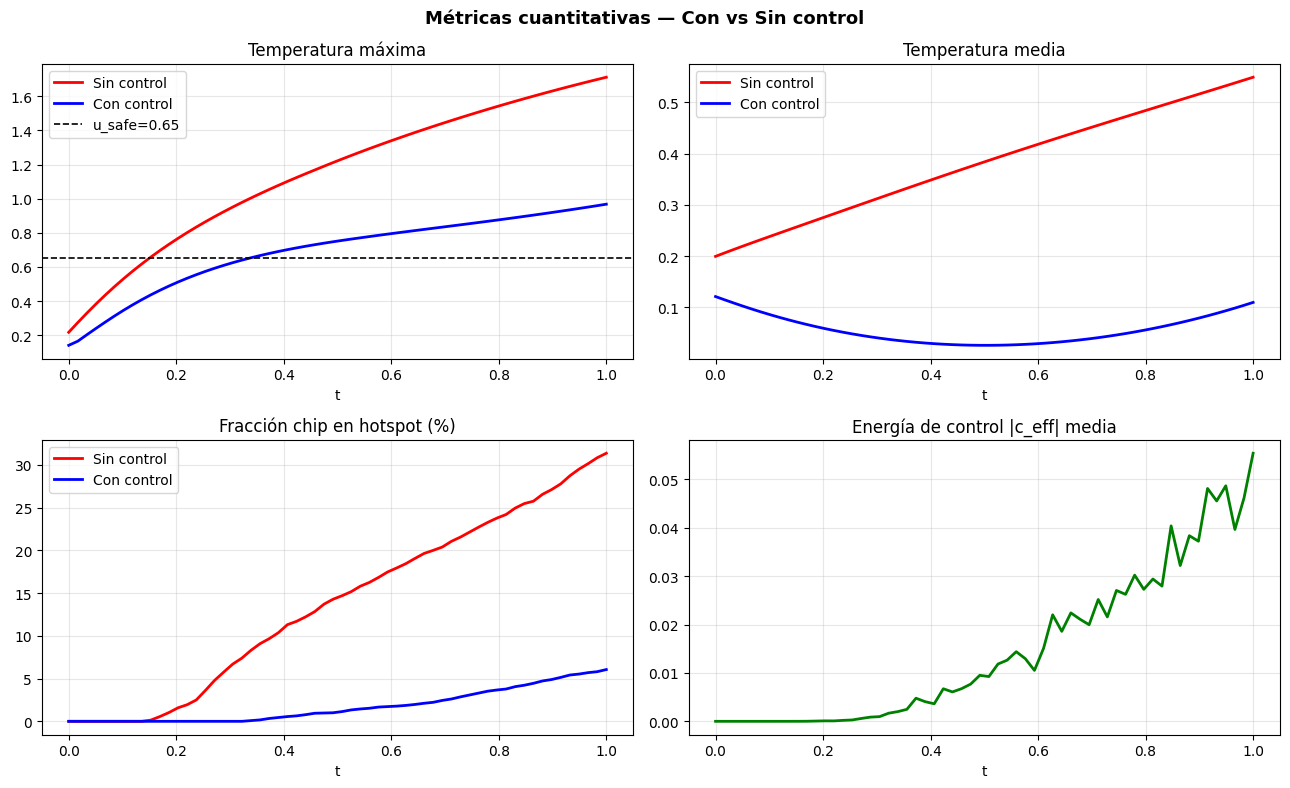

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# MÉTRICAS CUANTITATIVAS
# ═══════════════════════════════════════════════════════════════════════════════

t_metric = np.linspace(0, 1, 60)

metrics = dict(t=t_metric,
               u_max_ctrl=np.zeros(60),    u_max_noctrl=np.zeros(60),
               u_mean_ctrl=np.zeros(60),   u_mean_noctrl=np.zeros(60),
               hotspot_ctrl=np.zeros(60),  hotspot_noctrl=np.zeros(60),
               ctrl_energy=np.zeros(60))

for i, tv in enumerate(t_metric):
    uc  = eval_chip_ctrl(tv)
    unc = eval_chip_noctrl(tv)

    metrics["u_max_ctrl"][i]    = uc.max()
    metrics["u_max_noctrl"][i]  = unc.max()
    metrics["u_mean_ctrl"][i]   = uc.mean()
    metrics["u_mean_noctrl"][i] = unc.mean()
    metrics["hotspot_ctrl"][i]  = np.mean(uc  > u_safe)
    metrics["hotspot_noctrl"][i]= np.mean(unc > u_safe)

    with torch.no_grad():
        xm = torch.rand(1000,1,device=device)
        ym = torch.rand(1000,1,device=device)
        tm = torch.full((1000,1), tv, device=device)
        um = u_net(xm,ym,tm)
        g  = torch.sigmoid(k_gate*(um - u_safe))
        cr = c_net(xm,ym,tm)
        metrics["ctrl_energy"][i] = (g*cr).abs().mean().item()

# ── Resumen ───────────────────────────────────────────────────────────────────
dU   = (metrics["u_max_noctrl"][-1] - metrics["u_max_ctrl"][-1])
pctU = dU / max(metrics["u_max_noctrl"][-1], 1e-9) * 100
dHS  = metrics["hotspot_noctrl"].mean() - metrics["hotspot_ctrl"].mean()
pctHS= dHS / max(metrics["hotspot_noctrl"].mean(), 1e-9) * 100
E_ctrl = np.trapz(metrics["ctrl_energy"], t_metric)

print("═"*55)
print("MÉTRICAS DE DESEMPEÑO")
print("═"*55)
print(f"  T_max final  — SIN: {metrics['u_max_noctrl'][-1]:.4f}  CON: {metrics['u_max_ctrl'][-1]:.4f}  Δ={pctU:.1f}%")
print(f"  Área hotspot — SIN: {metrics['hotspot_noctrl'].mean()*100:.2f}%  CON: {metrics['hotspot_ctrl'].mean()*100:.2f}%  Δ={pctHS:.1f}%")
print(f"  Energía ctrl : {E_ctrl:.5f}")
print("═"*55)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Métricas cuantitativas — Con vs Sin control", fontsize=13, fontweight='bold')

ax=axes[0,0]
ax.plot(t_metric, metrics["u_max_noctrl"],'r-',lw=2,label="Sin control")
ax.plot(t_metric, metrics["u_max_ctrl"],  'b-',lw=2,label="Con control")
ax.axhline(u_safe,color='k',ls='--',lw=1.2,label=f"u_safe={u_safe}")
ax.set_title("Temperatura máxima"); ax.set_xlabel("t"); ax.legend(); ax.grid(alpha=.3)

ax=axes[0,1]
ax.plot(t_metric, metrics["u_mean_noctrl"],'r-',lw=2,label="Sin control")
ax.plot(t_metric, metrics["u_mean_ctrl"],  'b-',lw=2,label="Con control")
ax.set_title("Temperatura media"); ax.set_xlabel("t"); ax.legend(); ax.grid(alpha=.3)

ax=axes[1,0]
ax.plot(t_metric, metrics["hotspot_noctrl"]*100,'r-',lw=2,label="Sin control")
ax.plot(t_metric, metrics["hotspot_ctrl"]*100,  'b-',lw=2,label="Con control")
ax.set_title("Fracción chip en hotspot (%)"); ax.set_xlabel("t"); ax.legend(); ax.grid(alpha=.3)

ax=axes[1,1]
ax.plot(t_metric, metrics["ctrl_energy"],'g-',lw=2)
ax.set_title("Energía de control |c_eff| media"); ax.set_xlabel("t"); ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig("thermal_metrics.png", dpi=120, bbox_inches='tight')
plt.show()


## 9. Visualización del gate y control activo

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DEL GATE Y DEL CONTROL EFECTIVO
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def eval_gate_and_control(t_val, n=N_VIS):
    """Retorna (gate_field, control_field) como np.arrays [n,n]"""
    u_net.eval(); c_net.eval()
    xs = torch.linspace(0, 1, n, device=device)
    ys = torch.linspace(0, 1, n, device=device)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')
    xf = Xg.reshape(-1, 1)
    yf = Yg.reshape(-1, 1)
    tf = torch.full_like(xf, t_val)

    u_f   = u_net(xf, yf, tf)
    gate  = thermal_gate(u_f)
    c_raw = c_net(xf, yf, tf)
    c_eff = gate * c_raw

    return (gate.reshape(n, n).cpu().numpy(),
            c_eff.reshape(n, n).cpu().numpy())

t_show = 0.6   # tiempo donde el control debería estar más activo

gate_f, ctrl_f = eval_gate_and_control(t_show)
u_at_t = eval_chip(t_show, include_control=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Campos del control adaptativo en t={t_show}", fontsize=13)

data_titles = [
    (u_at_t,   "Temperatura u(x,y)", 'hot',     "u"),
    (gate_f,   f"Gate σ(k·(u−u_safe))", 'RdYlGn_r', "gate"),
    (ctrl_f,   "Control efectivo c(x,y,t)", 'coolwarm', "c (extracción)"),
]

for ax, (data, title, cmap, label) in zip(axes, data_titles):
    im = ax.imshow(data.T, origin='lower', extent=[0,1,0,1],
                   cmap=cmap, aspect='equal')
    plt.colorbar(im, ax=ax, label=label, fraction=0.046)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")

    if "Gate" in title:
        ax.contour(np.linspace(0,1,N_VIS), np.linspace(0,1,N_VIS), data.T,
                   levels=[0.5], colors='k', linewidths=1.2, linestyles='--')
        ax.text(0.02, 0.02, 'gate=0.5 contour', color='k',
                fontsize=7, transform=ax.transAxes)

    for (cx, cy) in HEAT_CENTERS:
        ax.plot(cx, cy, 'w+' if 'hot' in cmap else 'k+',
                markersize=9, markeredgewidth=2)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/gate_control_visualization.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("Visualización del gate guardada ✓")
print()
print("Interpretación:")
print("  - El gate es ~0 donde el chip está frío → control inactivo")
print("  - El gate es ~1 en hotspots → control totalmente activo")
print("  - c(x,y,t) ≤ 0 siempre: extrae calor, nunca lo añade")


NameError: name 'eval_chip' is not defined

## 10. Visualización de la fuente de calor Q(x,y)

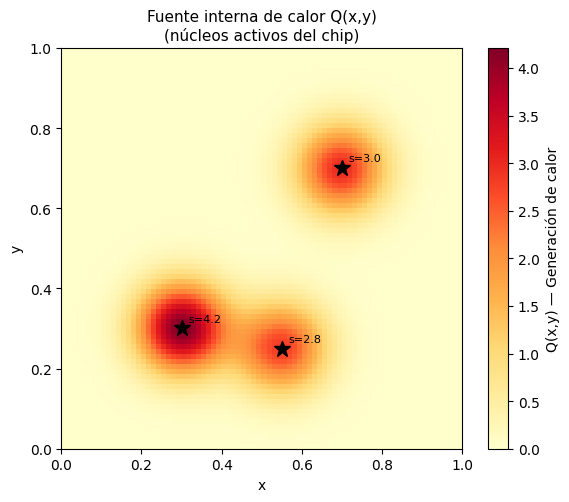

Fuente de calor visualizada ✓


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# FUENTE DE CALOR — VISUALIZACIÓN
# ═══════════════════════════════════════════════════════════════════════════════

n_q = 80
xs_q = torch.linspace(0, 1, n_q, device=device)
ys_q = torch.linspace(0, 1, n_q, device=device)
Xq, Yq = torch.meshgrid(xs_q, ys_q, indexing='ij')
Q_field = heat_source(Xq.reshape(-1,1), Yq.reshape(-1,1))
Q_field = Q_field.reshape(n_q, n_q).cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Q_field.T, origin='lower', extent=[0,1,0,1],
               cmap='YlOrRd', aspect='equal')
plt.colorbar(im, ax=ax, label='Q(x,y) — Generación de calor')
ax.set_title("Fuente interna de calor Q(x,y)\n(núcleos activos del chip)", fontsize=11)
ax.set_xlabel("x"); ax.set_ylabel("y")

for (cx, cy), s in zip(HEAT_CENTERS, HEAT_STRENGTHS):
    ax.plot(cx, cy, 'k*', markersize=12)
    ax.annotate(f"s={s}", (cx, cy), textcoords="offset points",
                xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.savefig("heat_source.png", dpi=120, bbox_inches='tight')
plt.show()
print("Fuente de calor visualizada ✓")


## 11. Mejoras futuras y extensiones

### A. Física más rica
| Extensión | Descripción |
|---|---|
| **Hotspots móviles** | `Q(x,y,t)` con centros que varían en el tiempo (carga dinámica del chip) |
| **Materiales anisotrópicos** | Tensor de difusividad `α(x,y)` — e.g., silicon vs cobre |
| **Histéresis térmica** | Modelar lag entre detección de hotspot y activación del control |
| **Chips heterogéneos** | Distintas zonas con diferentes α, Q_max, u_safe |

### B. Control avanzado
| Extensión | Descripción |
|---|---|
| **Control por RL** | Entrenar un agente que aprenda política de cooling óptima |
| **MPC (Model Predictive Control)** | Usar la PINN como modelo de predicción en bucle de control |
| **Control discreto** | Modelar switching de frecuencias (activo/inactivo) con relajación convexa |
| **Multi-zona** | Control independiente por región del chip |

### C. Mejoras de la PINN
| Extensión | Descripción |
|---|---|
| **Fourier Features** | Codificar (x,y,t) con funciones de Fourier para mejorar captura de altas frecuencias |
| **Adaptive loss weighting** | Actualizar λ automáticamente (e.g., método NTK o self-adaptive PINNs) |
| **Separación u = û + ũ** | Separar solución particular (satisface IC exactamente) de red libre |
| **Transfer learning** | Pre-entrenar con casos simples y fine-tunear en geometrías complejas |
| **DeepONet** | Operador neural para distintas condiciones de carga sin re-entrenar |

### D. Validación
| Extensión | Descripción |
|---|---|
| **FEM/FDM ground truth** | Comparar con solución numérica clásica de la ecuación del calor |
| **Datos experimentales** | Integrar lecturas de sensores IR de chips reales |
| **Incertidumbre** | PINN bayesiana para cuantificar incertidumbre en la predicción térmica |
